# Exercise 12: image recognition

**The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).**



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import utils
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

## 12.1
**Change at will and train your DNN by increasing the number of epochs to an adequate value. Try to use at least two other optimizers, different from SGD: watch to accuracy and loss for training and validation data and comment on the performances.**

To generate the MNIST training and test datasets, I implemented a function in the `utils.py` module, which can be used for both Deep Neural Networks (DNNs) and Convolutional Neural Networks (CNNs).

The first model I analyze is a **sequential DNN** with a fixed architecture. In order to compare different optimization strategies, I initially trained several DNNs sharing the same architecture but using different optimizers, running each training for a relatively small number of epochs.


In [2]:
# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

In [7]:
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(layers.Dense(400,input_shape=(img_rows*img_cols,), activation='relu'))
    # add a dense all-to-all relu layer
    model.add(layers.Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(layers.Dropout(0.5))
    # soft-max layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.summary()

/home/elisa/miniconda3/envs/thesis/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
optimizers_to_test = ["sgd","adam","nadam", "adamax","rmsprop"]
histories = []
times=[]
predictions = []
batch_size = 32
epochs = 10
for opt in optimizers_to_test:
    X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes)
    time,hist,pred = utils.test_DNN(img_rows,img_cols,num_classes,X_train,Y_train,X_test,Y_test,batch_size,epochs,opt,return_pred=True)
    histories.append(hist)
    times.append(time)
    predictions.append(pred)

/home/elisa/miniconda3/envs/thesis/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - acc: 0.6582 - loss: 1.1305 - val_acc: 0.9153 - val_loss: 0.3092
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.8884 - loss: 0.3999 - val_acc: 0.9312 - val_loss: 0.2373
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9112 - loss: 0.3183 - val_acc: 0.9407 - val_loss: 0.1986
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9237 - loss: 0.2703 - val_acc: 0.9474 - val_loss: 0.1746
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9335 - loss: 0.2429 - val_acc: 0.9524 - val_loss: 0.1587
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9394 - loss: 0.2167 - val_acc: 0.9553 - val_loss: 0.1447
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9443 - loss: 0.1963 - val_acc: 0.9582 - val_loss: 0.1363
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9486 - loss: 0.1837 - val_acc: 0.9604 - val_loss: 0.1257
Epoch 9/10
1875/1875 ━━━━━━━━━━━

In [10]:
for i,t in enumerate(times):
    print(f'Optimizer {optimizers_to_test[i]} took {t} seconds')

Optimizer sgd took 91.7876787185669 seconds
Optimizer adam took 147.3439564704895 seconds
Optimizer nadam took 155.77567982673645 seconds
Optimizer adamax took 155.0647406578064 seconds
Optimizer rmsprop took 134.12365651130676 seconds


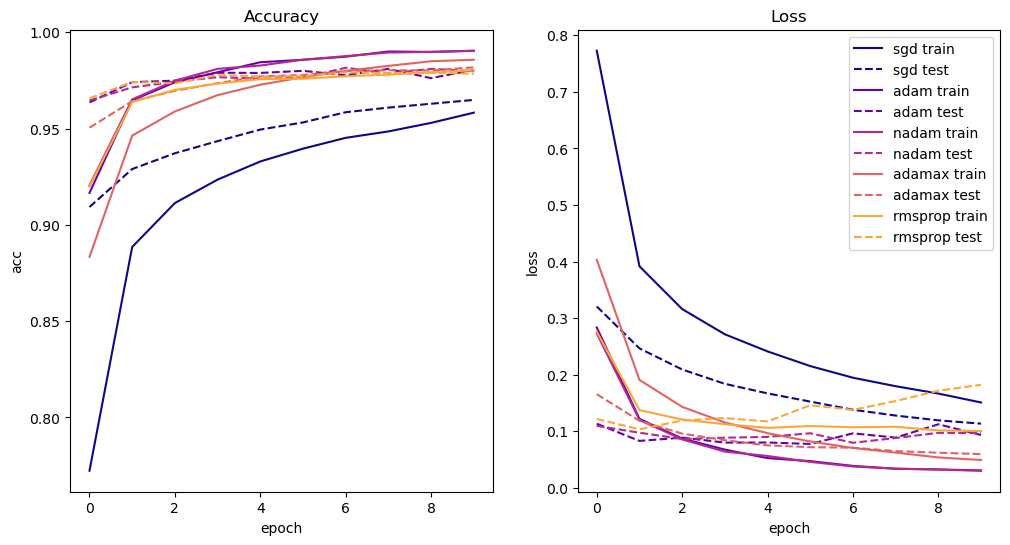

In [11]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(histories)+1))
ax[0].set_title ("Accuracy")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("acc")
ax[1].set_title("Loss")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("loss")
for i in range(len(histories)):
    ax[0].plot(histories[i].history["acc"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[0].plot(histories[i].history["val_acc"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

        
    ax[1].plot(histories[i].history["loss"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[1].plot(histories[i].history["val_loss"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

plt.legend()
plt.show()

- At first glance, the best results seem to be obtained with the Adam and Nadam optimizers; however, the test loss appears to stagnate, which may indicate the onset of overfitting.
- In contrast, Adamax shows a continuously decreasing test loss, suggesting better generalization behavior.
- RMSprop clearly exhibits overfitting, as evidenced by the divergence between training and test performance.
- SGD shows a higher but rapidly decreasing loss, so when trained on more epochs it might be able to achieve better results

In conclusion, the best looking candidates are **Adamax** and **SGD**

In [37]:
epochs = 20
times,histories,predictions,X_test_list,Y_test_list = [],[],[],[],[]

optimizers_to_test = ['sgd','adamax']

for opt in optimizers_to_test:
    X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes)
    time,hist,pred = utils.test_DNN(img_rows,img_cols,num_classes,X_train,Y_train,X_test,Y_test,batch_size,epochs,opt,return_pred=True)
    histories.append(hist)
    times.append(time)
    predictions.append(pred)
    X_test_list.append(X_test)
    Y_test_list.append(Y_test)
    eps = np.linspace(1,epochs,epochs)
    with open(f"./OUTPUT/{opt}_DNN_test.csv","w") as out:
        out.write("epoch\tloss\tval_loss\tacc\tval_acc\n")
        for i in range(len(hist.history['loss'])):
            out.write(f"{eps[i]}\t{hist.history['loss'][i]}\t{hist.history['val_loss'][i]}\t{hist.history['acc'][i]}\t{hist.history['val_acc'][i]}\n")

/home/elisa/miniconda3/envs/thesis/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.6401 - loss: 1.1641 - val_acc: 0.9135 - val_loss: 0.3134
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.8809 - loss: 0.4141 - val_acc: 0.9287 - val_loss: 0.2423
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9075 - loss: 0.3286 - val_acc: 0.9399 - val_loss: 0.2052
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9206 - loss: 0.2763 - val_acc: 0.9474 - val_loss: 0.1764
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9311 - loss: 0.2424 - val_acc: 0.9526 - val_loss: 0.1599
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9387 - loss: 0.2191 - val_acc: 0.9567 - val_loss: 0.1440
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9443 - loss: 0.1990 - val_acc: 0.9594 - val_loss: 0.1330
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9482 - loss: 0.1844 - val_acc: 0.9619 - val_loss: 0.1238
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━

computation times:


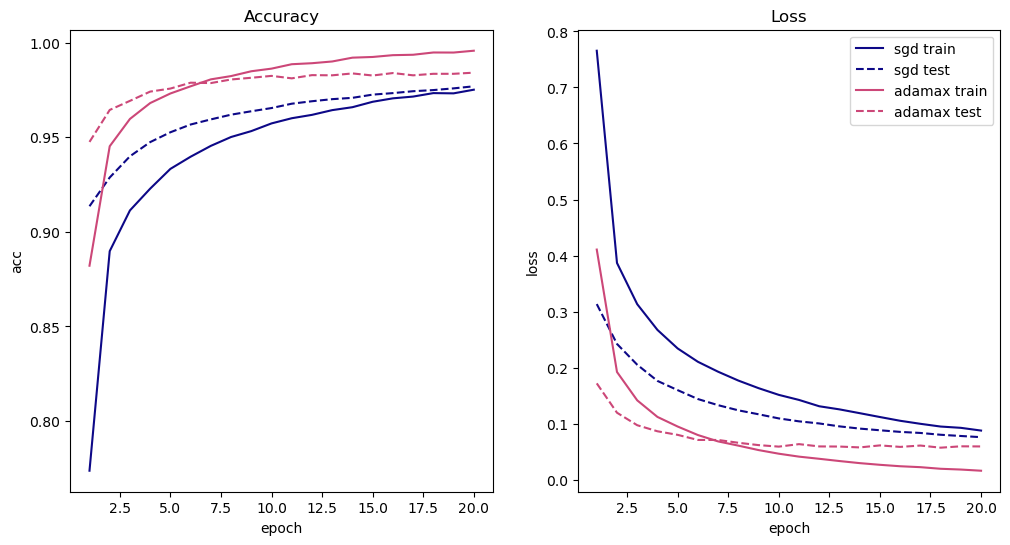

In [38]:

fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 3))
ax[0].set_title ("Accuracy")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("acc")
ax[1].set_title("Loss")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("loss")
print('computation times:')
#print(times)
#for i,t in enumerate(times):
    #print(f'{optimizers_to_test[i]} took {t} seconds')

for i in range(len(histories)):

    df = pd.read_csv(f"./OUTPUT/{optimizers_to_test[i]}_DNN_test.csv",sep = '\t')
    ax[0].plot(df['epoch'],df["acc"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[0].plot(df['epoch'],df["val_acc"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

        
    ax[1].plot(df['epoch'],df["loss"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[1].plot(df['epoch'],df["val_loss"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

plt.legend()
plt.show()

In conclusion, **Adamax** looks like the best choice of optimizer for a DNN with this architecture.

## 12.2

**Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end.**

I tested several CNN configurations, and my final choice was an architecture that alternates a convolutional layer and a max-pooling layer twice. I observed that when the kernel size is chosen to be too small, or the number of filters is too large, the CNN tends to exhibit overfitting. This behavior is evident from the fact that the network achieves nearly perfect predictions on the MNIST dataset it is trained on, but fails to generalize to digits drawn by me.


In [6]:
#model 1
from keras import layers
models = []
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')

model = Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(10, kernel_size=(5,5), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2),padding='valid'),
        layers.Conv2D(16, kernel_size=(5,5), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2),strides=1,padding='valid'),
        layers.Flatten(),
        layers.Dense(100,activation="relu"),
        
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer='Adamax',metrics=['accuracy'])



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         4,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,786 (327.29 KB)

 Trainable params: 83,786 (327.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

epochs=20
batch_size=32  
import time

t0=time.time()
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')

model.compile(loss=keras.losses.categorical_crossentropy,
            optimizer='Adamax',metrics=['acc'])

hist = model.fit(X_train, Y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, Y_test))
t1=time.time()

eps = np.linspace(0,epochs-1,epochs)

score= model.evaluate(X_test, Y_test,verbose=1)

print(f'time\t{t1-t0}')
print(f'test loss:\t{score[0]}')
print(f'test accuracy:\t{score[1]}')
model.save('./OUTPUT/model_CNN.keras') 

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - acc: 0.7960 - loss: 2.1208 - val_acc: 0.9534 - val_loss: 0.1642
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - acc: 0.9583 - loss: 0.1573 - val_acc: 0.9703 - val_loss: 0.0994
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - acc: 0.9766 - loss: 0.0832 - val_acc: 0.9783 - val_loss: 0.0759
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - acc: 0.9848 - loss: 0.0530 - val_acc: 0.9793 - val_loss: 0.0717
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - acc: 0.9891 - loss: 0.0376 - val_acc: 0.9819 - val_loss: 0.0685
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - acc: 0.9923 - loss: 0.0268 - val_acc: 0.9830 - val_loss: 0.0669
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.9947 - loss: 0.0194 - val_acc: 0.9848 - val_loss: 0.0730
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - acc: 0.9959 - loss: 0.0139 - val_acc: 0.9865 - val_loss: 0.0626
Epoch 9/20
1875/1875 ━━━

In [8]:
with open(f"./OUTPUT/CNN_test.csv","w") as out:
        out.write("epoch\tloss\tval_loss\tacc\tval_acc\n")
        for i in range(len(hist.history['loss'])):
            out.write(f"{eps[i]}\t{hist.history['loss'][i]}\t{hist.history['val_loss'][i]}\t{hist.history['acc'][i]}\t{hist.history['val_acc'][i]}\n")

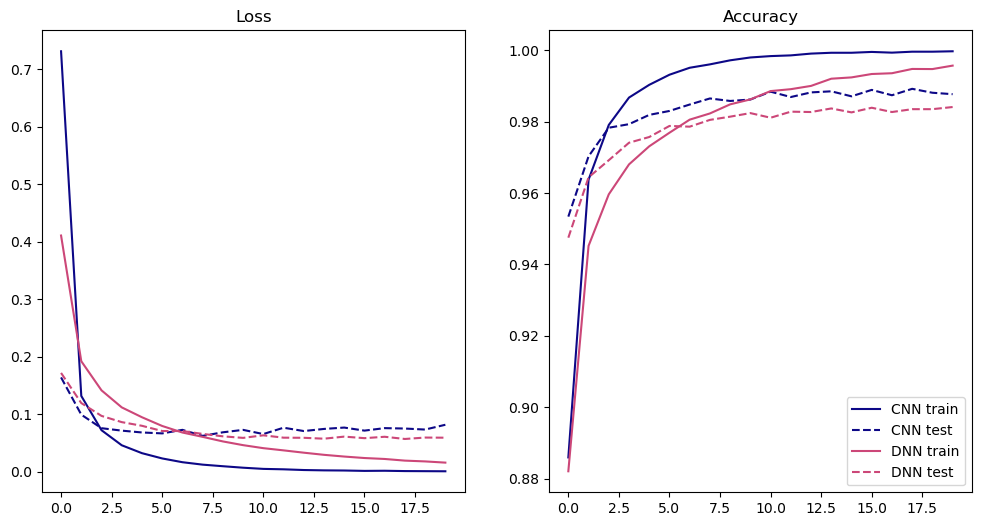

In [12]:
#comparison with DNN

dnn_df = pd.read_csv("./OUTPUT/adamax_DNN_test.csv",sep='\t')
cnn_df = pd.read_csv("./OUTPUT/CNN_test.csv",sep='\t')
fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 3))

ax[0].plot(cnn_df['epoch'],cnn_df['loss'],c=colors[0],label = 'CNN train')
ax[0].plot(cnn_df['epoch'],cnn_df['val_loss'],c=colors[0],linestyle='dashed',label = 'CNN test')
ax[0].plot(dnn_df['epoch'][:20]-1,dnn_df['loss'][:20],c=colors[1],label = 'DNN train')
ax[0].plot(dnn_df['epoch'][:20]-1,dnn_df['val_loss'][:20],c=colors[1],linestyle='dashed',label = 'DNN test')

ax[1].plot(cnn_df['epoch'],cnn_df['acc'],c=colors[0],label = 'CNN train')
ax[1].plot(hist.history['val_acc'],c=colors[0],linestyle='dashed',label = 'CNN test')
ax[1].plot(dnn_df['epoch'][:20]-1,dnn_df['acc'][:20],c=colors[1],label = 'DNN train')
ax[1].plot(dnn_df['epoch'][:20]-1,dnn_df['val_acc'][:20],c=colors[1],linestyle='dashed',label = 'DNN test')
plt.legend()
ax[0].set_title('Loss')
ax[1].set_title('Accuracy')
plt.show()

In [14]:
DNN_model = tf.keras.models.load_model(
    "./OUTPUT/models/DNN_test_adamax_20.keras", custom_objects=None, compile=True, safe_mode=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


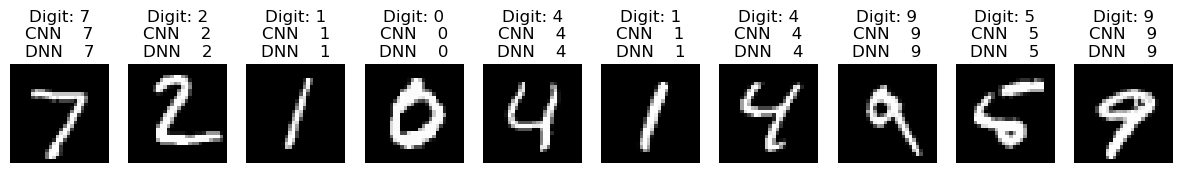

In [20]:
import matplotlib.pyplot as plt
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')
DNNX_train,DNNY_train,DNNX_test,DNNY_test,DNNinput_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='DNN')
predictions = model.predict(X_test)
DNN_pred = DNN_model.predict(DNNX_test)
plt.figure(figsize=(15, 15)) 

X_test=X_test.reshape(X_test.shape[0],img_rows,img_cols,1)
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nCNN    {}\nDNN    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i]),np.argmax(DNN_pred[i])))    
    plt.axis('off') 
plt.show()

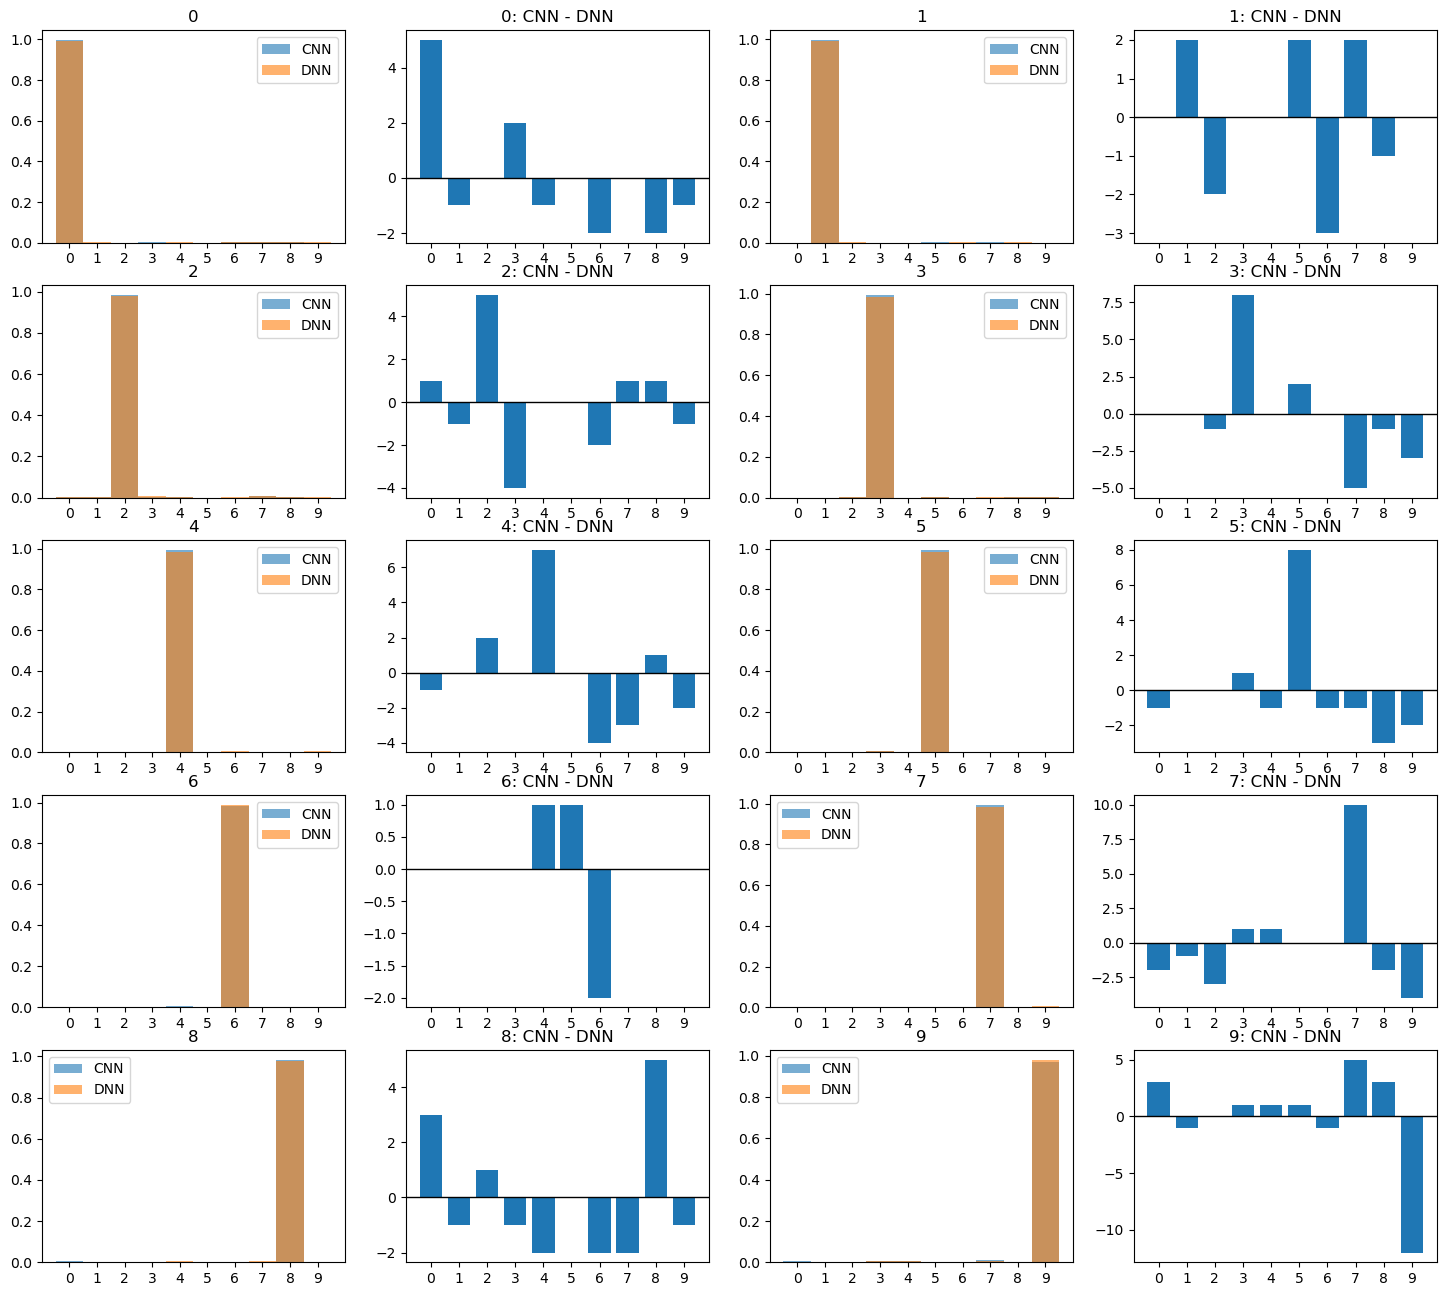

In [23]:
bins = np.linspace(-0.5, 9.5, 11)
fig, ax = plt.subplots(5, 4, figsize=(18, 16))
ax = ax.flatten()

for j in range(10):

    # Pick the axes: histogram on the left, difference on the right
    ax_hist = ax[2*j]
    ax_diff = ax[2*j + 1]

    mask = Y_test[:, j] == 1
    y_pred = np.argmax(predictions[mask], axis=1)
    DNNy_pred = np.argmax(DNN_pred[mask], axis=1)

    # --- Histogram (left plot) ---
    ax_hist.hist(y_pred, bins=bins, density=True, alpha=0.6, label="CNN")
    ax_hist.hist(DNNy_pred, bins=bins, density=True, alpha=0.6, label="DNN")
    ax_hist.set_title(j)
    ax_hist.set_xticks(range(10))
    ax_hist.legend()

    # --- Compute histogram difference ---
    hist1, _ = np.histogram(y_pred, bins=bins)
    hist2, _ = np.histogram(DNNy_pred, bins=bins)
    diff = hist1 - hist2

    # --- Difference plot (right plot) ---
    ax_diff.bar(range(10), diff, width=0.8)
    ax_diff.axhline(0, color='black', linewidth=1)
    ax_diff.set_title(f"{j}: CNN - DNN")
    ax_diff.set_xticks(range(10))

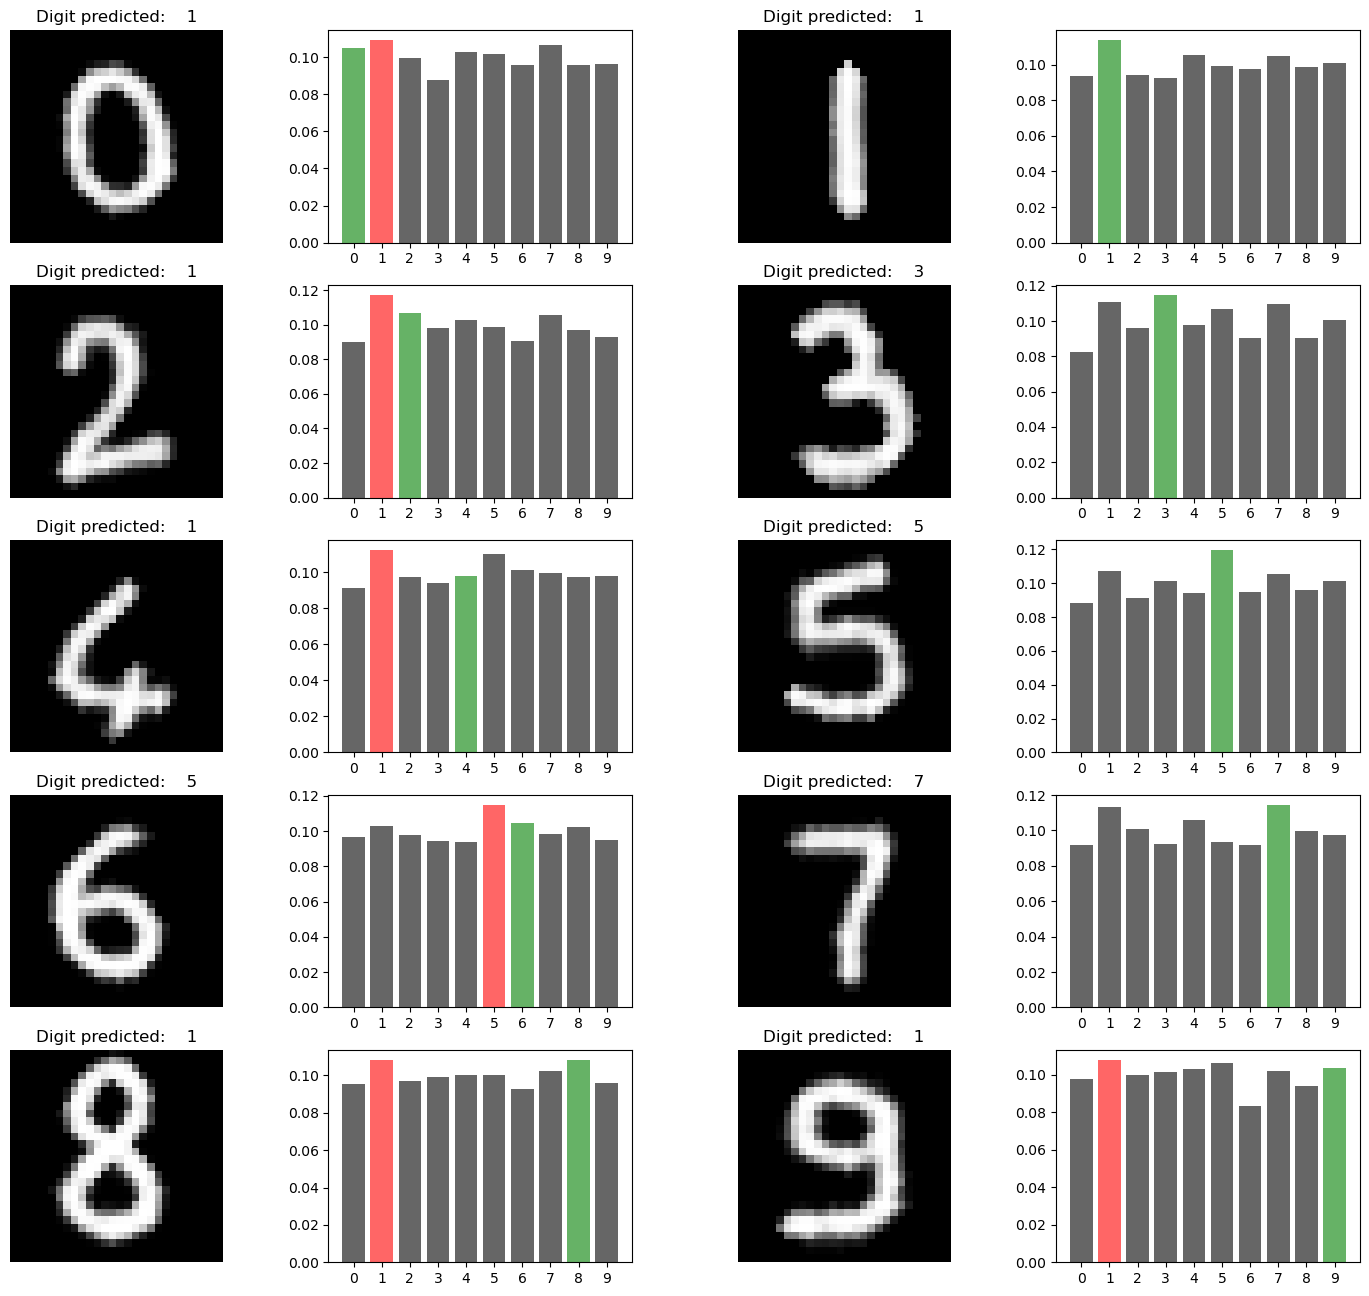

In [19]:


from PIL import Image
import os

fig, ax = plt.subplots(5, 4, figsize=(18, 16))
ax = ax.flatten()
for k in range (10):
    ax_fig = ax[2*k]
    ax_hist = ax[2*k + 1]
    digit_filename = f"./digits/{k}.png"
    digit_in = Image.open(digit_filename).convert('L')
    ydim, xdim = digit_in.size
    pix=digit_in.load();
    data = np.zeros((xdim, ydim))
    
    for j in range(ydim):
        for i in range(xdim):
            data[i,j]=pix[j,i]

    data /= 255

    data=data.reshape(1,xdim,ydim,1)

    pred= model.predict(data,verbose=0) 

    data = data.reshape(xdim,ydim)
  
    imax = np.argmax(pred[0])

# Default color for all bars
    colors = ['black'] * 10           
    colors[k] = 'green'   
    if (k==imax) : colors[imax]='green'
    else: colors[imax]='red'# highlight max


  
    ax_fig.imshow(data, cmap='gray')    
    ax_fig.set_title("Digit predicted:    {}".format(np.argmax(pred)))
    ax_fig.axis('off') 
    bins=np.linspace(0,10,10)
    
    ax_hist.bar(range(10),pred[0],color=colors,alpha=0.6)
    ax_hist.set_xticks(range(10))



### Conclusions
The CNN shows a faster increase in accuracy compared to the DNN, and for most digits it achieves a higher number of correct predictions. This confirms the effectiveness of convolutional neural networks as a powerful tool for image recognition tasks.
